## Introducción

## Análisis de Movilidad Urbana y Productividad Económica en América Latina

Este análisis examina la relación entre indicadores de movilidad urbana (congestión vehicular, tiempos de viaje) y productividad económica (PIB per cápita) en ciudades latinoamericanas, utilizando datos de TomTom Traffic Index y OECD Cities. El objetivo es identificar oportunidades de inversión en infraestructura de transporte.

## 1. Ingesta y Exploración Inicial de Datos

Se procede a cargar las dependencias necesarias y los conjuntos de datos de fuentes primarias, realizando una exploración preliminar para validar la estructura y completitud de la información.


In [6]:
# Load required libraries for data processing, visualization, and analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import gdown


In [7]:

# Descargar TomTom Traffic desde Google Drive
traffic_file_id = "1GKKkybzladDfkA5O5YgitFVXvA5RHb-R"
traffic_url = f"https://drive.google.com/uc?id={traffic_file_id}"
gdown.download(traffic_url, 'tomtom_traffic.csv', quiet=False)

# Descargar OECD City Economy desde Google Drive
eco_file_id = "1E9kFsiDhUSfR6OPTiUxVNipnbGdF9Usf"
eco_url = f"https://drive.google.com/uc?id={eco_file_id}"
gdown.download(eco_url, 'oecd_city_economy.csv', quiet=False)

# Cargar datos
traffic = pd.read_csv('tomtom_traffic.csv')
eco = pd.read_csv('oecd_city_economy.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1GKKkybzladDfkA5O5YgitFVXvA5RHb-R
From (redirected): https://drive.google.com/uc?id=1GKKkybzladDfkA5O5YgitFVXvA5RHb-R&confirm=t&uuid=f971c67b-cee5-4294-b4bd-de9a1c3b1665
To: /content/tomtom_traffic.csv
100%|██████████| 149M/149M [00:01<00:00, 142MB/s]
Downloading...
From: https://drive.google.com/uc?id=1E9kFsiDhUSfR6OPTiUxVNipnbGdF9Usf
To: /content/oecd_city_economy.csv
100%|██████████| 1.75k/1.75k [00:00<00:00, 1.75MB/s]


In [8]:
print(traffic.head())

  Country       City            UpdateTimeUTC  JamsDelay  TrafficIndexLive  \
0     ARE  abu-dhabi  2025-01-13 04:01:30.001      650.7              36.0   
1     ARE  abu-dhabi  2025-01-13 03:46:00.000      540.4              30.0   
2     ARE  abu-dhabi  2025-01-13 02:46:30.000       71.8               7.0   
3     ARE  abu-dhabi  2025-01-13 01:46:30.001        8.2               2.0   
4     ARE  abu-dhabi  2025-01-13 00:01:30.000        1.1               1.0   

   JamsLengthInKms  JamsCount  TrafficIndexWeekAgo     UpdateTimeUTCWeekAgo  \
0            109.1      162.0                 30.0  2025-01-06 04:01:30.000   
1            101.4      136.0                 27.0  2025-01-06 03:46:30.001   
2             18.9       23.0                  6.0  2025-01-06 02:46:30.000   
3              4.1        2.0                  2.0  2025-01-06 01:46:30.000   
4              0.2        1.0                  1.0  2025-01-06 00:01:30.000   

   TravelTimeLivePer10KmsMins  TravelTimeHistoricPer10Km

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
eco.head()

,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"



---

## 2. Evaluación de Estructura y Calidad de Datos

Se realiza un diagnóstico integral de ambos datasets para identificar inconsistencias en tipos de datos, valores faltantes y formatos que requieran depuración.


---

## 2. Evaluación de Estructura y Calidad de Datos

Se realiza un diagnóstico integral de ambos datasets para identificar inconsistencias en tipos de datos, valores faltantes y formatos que requieran depuración.

In [11]:
# Examine structure of traffic dataset
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

**Diagnóstico del Dataset de Tráfico:**

El dataset contiene 1,004,464 registros sin valores nulos. Las columnas de fecha (`UpdateTimeUTC`, `UpdateTimeUTCWeekAgo`) requieren conversión a formato datetime. Los indicadores numéricos presentan tipos correctos (float64), y las dimensiones geográficas están adecuadamente codificadas como texto.

In [12]:

# Examine structure of economic dataset
eco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


**Diagnóstico del Dataset Económico:**

El dataset contiene 30 registros sin valores nulos. Las variables numéricas (`City GDP/capita`, `Unemployment %`, `PM2.5`, `Population`) están codificadas como texto debido a símbolos y delimitadores. Requieren limpieza y conversión a tipos numéricos para análisis cuantitativo.

### 2.1 Estandarización de Nomenclatura

Se normalizan los nombres de columnas al formato `snake_case` para garantizar consistencia y facilitar operaciones posteriores.


In [13]:
# Standardize column naming conventions to snake_case for traffic data
traffic = traffic.rename(columns={
    'Country': 'country',
    'City': 'city',
    'UpdateTimeUTC': 'update_time_utc',
    'JamsDelay': 'jams_delay',
    'TrafficIndexLive': 'traffic_index_live',
    'JamsLengthInKms': 'jams_length_kms',
    'JamsCount': 'jams_count',
    'TrafficIndexWeekAgo': 'traffic_index_week_ago',
    'UpdateTimeUTCWeekAgo': 'update_time_utc_week_ago',
    'TravelTimeLivePer10KmsMins': 'travel_time_live_10km_mins',
    'TravelTimeHistoricPer10KmsMins': 'travel_time_historic_10km_mins',
    'MinsDelay': 'mins_delay'
})
# Verify column name changes
traffic.columns

Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_10km_mins', 'travel_time_historic_10km_mins',
       'mins_delay'],
      dtype='object')

In [14]:
# Standardize column naming conventions to snake_case for economic data
eco = eco.rename(columns={
    'Year': 'year',
    'City': 'city',
    'Country': 'country',
    'City GDP/capita': 'city_gdp_capita',
    'Unemployment %': 'unemployment_pct',
    'PM2.5 (μg/m³)': 'pm25_level',
    'Population (M)': 'population_m'
})
# Verify column name changes
eco.columns

Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25_level', 'population_m'],
      dtype='object')


### 2.2 Conversión de Tipos de Datos

Se convierten campos de fecha a formato datetime y se depuran valores numéricos eliminando símbolos y delimitadores para garantizar precisión en análisis posteriores.


In [15]:
# Convert datetime columns to appropriate temporal format
traffic['update_time_utc'] = pd.to_datetime(traffic['update_time_utc'], errors='coerce')
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic['update_time_utc_week_ago'], errors='coerce')
# Verify data type conversions
traffic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype         
---  ------                          --------------    -----         
 0   country                         1004464 non-null  object        
 1   city                            1004464 non-null  object        
 2   update_time_utc                 1004464 non-null  datetime64[ns]
 3   jams_delay                      1004464 non-null  float64       
 4   traffic_index_live              1004464 non-null  float64       
 5   jams_length_kms                 1004464 non-null  float64       
 6   jams_count                      1004464 non-null  float64       
 7   traffic_index_week_ago          1004464 non-null  float64       
 8   update_time_utc_week_ago        1004464 non-null  datetime64[ns]
 9   travel_time_live_10km_mins      1004464 non-null  float64       
 10  travel_time_historic_10km_mins  1004464 no

In [16]:

# Clean numeric values in economic dataset by removing delimiters and symbols

eco['city_gdp_capita'] = eco['city_gdp_capita'].str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float)
# Clean unemployment: remove % symbol and standardize decimal notation
eco['unemployment_pct'] = eco['unemployment_pct'].str.replace('%', '').str.replace(',', '.').astype(float)


eco['population_m'] = eco['population_m'].str.replace(',', '.', regex=False).astype(float)

# Convert population from millions to absolute units
eco['population'] = eco['population_m'] * 1000000

# Verify data type conversions
eco.info()

eco.head(3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25_level        30 non-null     object 
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25_level,population_m,population
0,2023,buenos-aires,Argentina,15782.0,6.2,"15,2",15.3,15300000.0
1,2023,sao-paulo,Brazil,14475.0,9.1,"29,50",22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,13142.0,9.8,"19,10",13.6,13600000.0



## 3. Extracción de Período Temporal y Filtrado de Datos

Se extrae el componente temporal de los registros de tráfico y se aísla el período analítico (2024) para garantizar coherencia temporal en la integración de datasets.

In [17]:
# Extract year component from timestamp
traffic['year'] = pd.to_datetime(traffic["update_time_utc"]).dt.year

# Verify extraction operation
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232,2025


In [18]:
# Filter records for analytical period (2024)
traffic_2024 = traffic[traffic["year"] == 2024].copy()
eco_2024 = eco[eco["year"] == 2024].copy()

# Review filtered datasets
display(traffic_2024.head())
display(eco_2024.head())


,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_10km_mins,travel_time_historic_10km_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30.000,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30.000,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30.000,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30.000,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30.000,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00.000,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00.000,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25_level,population_m,population
15,2024,buenos-aires,Argentina,18117.0,7.2,"14,50",15.4,15400000.0
16,2024,sao-paulo,Brazil,14703.0,8.5,"28,00",22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,13349.0,9.2,"18,40",13.7,13700000.0
18,2024,brasilia,Brazil,16251.0,7.8,"12,80",4.8,4800000.0
19,2024,salvador,Brazil,8899.0,12.4,"15,20",3.9,3900000.0



## 4. Agregación de Indicadores de Movilidad

Dado que el dataset original contiene múltiples observaciones diarias por ciudad, se realiza agregación estadística a nivel anual por ciudad para obtener indicadores consolidados de desempeño de movilidad urbana.



<details>

<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).


In [19]:


# Aggregate traffic metrics at city-year level

traffic_city_year_2024 = traffic_2024.groupby(['city', 'country', 'year'])[
    ['jams_delay', 'traffic_index_live', 'jams_length_kms',
     'jams_count', 'mins_delay', 'travel_time_live_10km_mins',
     'travel_time_historic_10km_mins']
].mean().reset_index()


# Display aggregated traffic summary
traffic_city_year_2024.head()



,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_10km_mins,travel_time_historic_10km_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


In [20]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_10km_mins,travel_time_historic_10km_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es ...


## 5. Integración de Datos: Movilidad y Economía

Se realiza operación de unión (INNER JOIN) entre datasets de tráfico y economía, utilizando ciudad y año como claves de integración para generar un dataset unificado que permite análisis correlacionales.


In [21]:

# Select relevant variables for integration
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
         'travel_time_live_10km_mins','travel_time_historic_10km_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25_level','population']

# Create independent subsets to avoid unintended modifications
traffic_2024_small = traffic_city_year_2024[ left_cols ].copy()
eco_2024_small = eco_2024[ right_cols ].copy()


# Perform inner join to combine traffic and economic indicators
merged = pd.merge(traffic_2024_small,eco_2024_small,on=["city","year"],how="inner")

print(merged.head())


             city country  year   jams_delay  traffic_index_live  \
0  belo-horizonte     BRA  2024   263.047879           19.428946   
1          bogota     COL  2024  1141.552364           37.614273   
2        brasilia     BRA  2024   101.576326           11.258220   
3    buenos-aires     ARG  2024   571.089593           17.756012   
4        curitiba     BRA  2024   183.469274           14.954545   

   jams_length_kms  jams_count  mins_delay  travel_time_live_10km_mins  \
0        44.038129   68.805422    0.487228                   18.304538   
1       140.893564  230.566550    1.699628                   24.992185   
2        18.337133   27.280140    0.193442                   13.338658   
3       100.287844  137.359860    0.416566                   17.907916   
4        30.050044   46.898164    0.139965                   17.258700   

   travel_time_historic_10km_mins  city_gdp_capita  unemployment_pct  \
0                       17.817311          11124.0               9.5   
1 


## 6. Análisis Exploratorio Visual

Se generan visualizaciones que permiten evaluar la distribución de indicadores de tráfico y PIB per cápita, facilitando la identificación de patrones, outliers y asociaciones potenciales entre ambas variables.

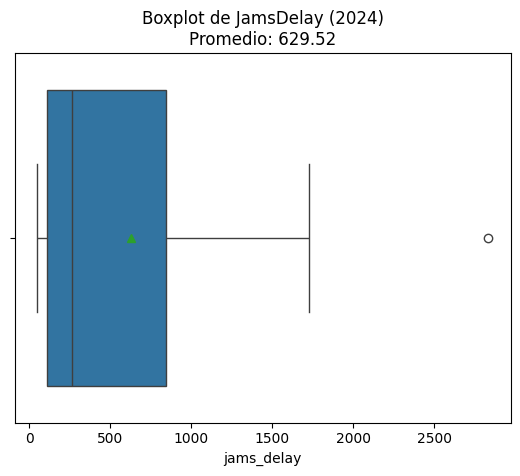

In [22]:
# Analyze traffic congestion distribution and central tendency

sns.boxplot(data=merged, x='jams_delay', showmeans=True)

mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()


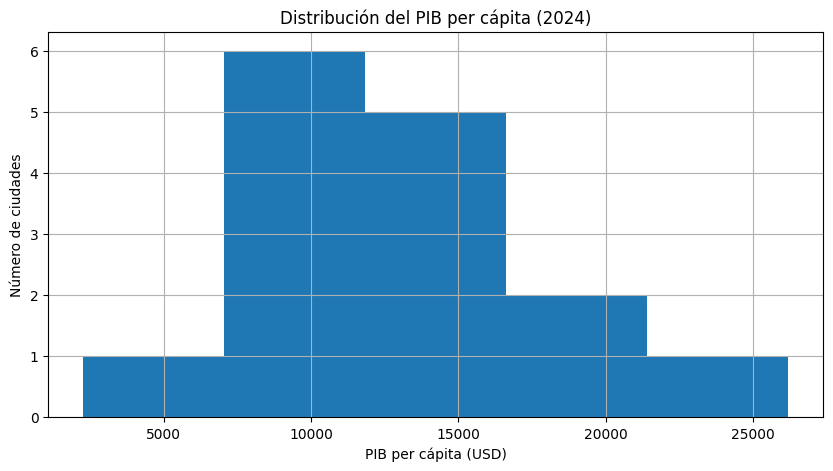

In [23]:

# Visualize distribution of economic productivity (GDP per capita)
merged['city_gdp_capita'].hist(bins=5, figsize=(10,5))
plt.title('Distribución del PIB per cápita (2024)')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Número de ciudades')
plt.show()


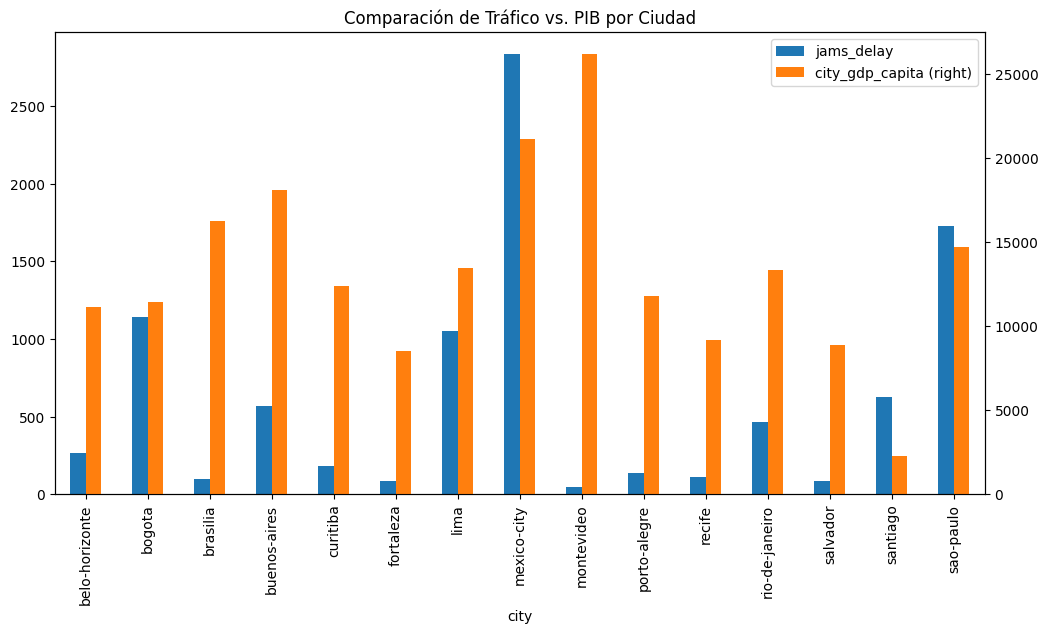

In [24]:
# Comparative analysis of traffic congestion and economic productivity by city
merged.plot(
    x='city',
    y=['jams_delay', 'city_gdp_capita'],
    kind='bar',
    secondary_y=['city_gdp_capita'],
    figsize=(12, 6)
)

plt.xticks(rotation=90)
plt.title('Comparación de Tráfico vs. PIB por Ciudad')


plt.show()



Escribe tus comentarios:


## 7. Exportación de Dataset Consolidado

Se genera el archivo de salida en formato CSV que contiene la información unificada y depurada, preparada para análisis posterior o compartición con stakeholders.


In [25]:
# Export consolidated and cleaned dataset for downstream analysis
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)



---

# 🧾 Resumen ejecutivo (plantilla)

> Completa este resumen al finalizar el análisis. Mantén 3–5 párrafos cortos, claros y accionables.

**Contexto & objetivo:**  
- Responde la pregunta central del análisis: ¿qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
- Explica brevemente las variables clave utilizadas y su relevancia para la toma de decisiones.

**Cobertura de datos:**  
- Especifica los años analizados, número de ciudades y países incluidos.

**Metodología (alto nivel):**  
- Describe los procesos principales: limpieza de datos (formatos, estandarización de columnas).
- Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
- Menciona las validaciones visuales empleadas (distribuciones, outliers, tendencias generales).

**Hallazgos iniciales:**  
- Resume los patrones más importantes entre índices de tráfico y PIB per cápita.

- Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.


**Recomendaciones**  
Aterriza los hallazgos en acciones: ciudades prioritarias, necesidad de validar fuentes, requerimiento de análisis adicionales, o propuestas de inversión.

- ¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?




# Resumen Ejecutivo: Movilidad Urbana y Productividad Económica (2024)

## Contexto y objetivo, Datos y Metodología

Este análisis examina la relación entre movilidad urbana —medida a través de congestión vehicular, tiempos de viaje e índice de tráfico— y productividad económica, representada por el PIB per cápita en ciudades latinoamericanas durante 2024. El objetivo principal fue identificar si mayores niveles de congestión se asocian con menores niveles de productividad económica urbana, aportando evidencia para decisiones de inversión en infraestructura y planificación de transporte.

### Cobertura de datos

- **Período analizado:** 2024  
- **Fuentes utilizadas:** TomTom Traffic Index + OECD Cities (indicadores económicos urbanos)
- **Cobertura:** 15 ciudades de América Latina pertenecientes a 7 países  
- **Variables clave:**  
  - `traffic_index_live` → nivel de congestión urbana  
  - `travel_time_live_10km_mins` → tiempo promedio de viaje por 10 km  
  - `jams_delay` → retraso acumulado por congestión  
  - `city_gdp_capita` → productividad económica urbana (PIB per cápita)

### Metodología aplicada

Se realizó un proceso de limpieza y estandarización de datos, incluyendo formatos numéricos, nombres de ciudades y normalización de columnas. Posteriormente, los indicadores fueron agregados a nivel ciudad–año y unidos mediante un `INNER`, garantizando que únicamente se analizaran registros con información completa tanto de movilidad como económica. El dataset final integró indicadores comparables para análisis exploratorio y correlacional.

La validación incluyó análisis visuales mediante histogramas, boxplots y gráficos comparativos para detectar distribuciones atípicas, tendencias generales y posibles outliers. Esto permitió verificar consistencia en los datos antes de interpretar relaciones entre congestión y productividad.

---

## Hallazgos Iniciales: Relación entre Congestión y Productividad

Los resultados muestran una relación moderada entre altos niveles de congestión y menores niveles de productividad económica, aunque no completamente lineal. Las ciudades con mayores tiempos de desplazamiento tienden a presentar presiones sobre eficiencia urbana y competitividad económica.

### Bogotá como caso prioritario

Bogotá se destacó como la ciudad con los mayores niveles de congestión dentro del conjunto analizado:

- **Traffic Index:** ≈ 37.6  
- **Altos tiempos promedio de viaje**  
- **PIB per cápita relativamente bajo frente a ciudades comparables**

La combinación de congestión severa y productividad moderada posiciona a Bogotá como la ciudad con mayor evidencia de impacto negativo potencial de la movilidad sobre el desempeño económico.

### Comparación regional

Lima también presentó niveles elevados de congestión y tiempos de desplazamiento altos, aunque con indicadores económicos ligeramente superiores. En contraste, Buenos Aires mostró menores niveles relativos de congestión y mejores indicadores económicos, sugiriendo una relación más equilibrada entre movilidad y productividad urbana.

### Outliers y observaciones relevantes

Se identificaron posibles outliers como:
- **Mexico City:** destacó como un outlier importante al presentar niveles de congestión significativamente superiores al resto de ciudades analizadas. Este comportamiento podría requerir una validación adicional de la fuente o un análisis más profundo sobre el impacto de la escala urbana en los indicadores de movilidad.”
- **Montevideo:** alto PIB per cápita con congestión moderada  
- **Santiago:** desempeño económico superior al esperado respecto a sus indicadores de tráfico  
- Algunas ciudades brasileñas mostraron diferencias importantes entre congestión y productividad, indicando que factores estructurales adicionales podrían influir en el desempeño económico urbano.

Estos casos requieren validación adicional y análisis complementarios antes de establecer conclusiones causales definitivas.

---

## Recomendaciones y Conclusiones

Bogotá surge como la ciudad prioritaria para inversión en infraestructura de transporte, debido a la combinación de alta congestión, tiempos de viaje elevados y productividad económica relativamente limitada. Los resultados sugieren que mejoras en movilidad podrían generar impactos positivos sobre competitividad y eficiencia urbana.

### Acciones recomendadas

- Expansión y modernización de sistemas de transporte masivo  
- Optimización semafórica y gestión inteligente del tráfico  
- Integración multimodal de transporte público  
- Incentivos para teletrabajo y horarios laborales flexibles  
- Fortalecimiento de políticas de movilidad sostenible

### Análisis adicionales sugeridos

- Profundizar el análisis visual entre congestión vehicular y PIB per cápita utilizando más gráficos comparativos entre ciudades.
- Revisar posibles valores atípicos (outliers) en ciudades con niveles de tráfico o PIB significativamente diferentes al resto.
- Incorporar información adicional sobre transporte público y crecimiento poblacional para enriquecer el análisis.
- Ampliar la cobertura temporal del dataset para comparar cambios entre distintos años.
- Validar la consistencia de algunas fuentes económicas y de movilidad para asegurar calidad en los datos.
- Priorizar estudios de movilidad en ciudades con altos niveles de congestión como Bogotá, debido a su posible impacto sobre la productividad urbana.

En conclusión, los resultados respaldan la hipótesis de que una movilidad urbana ineficiente puede limitar la productividad económica. Bogotá representa el caso más crítico dentro del análisis y debería considerarse una prioridad estratégica para futuras inversiones en infraestructura y planificación urbana.
